<a href="https://colab.research.google.com/github/danielsmith-cloud/DSRP_inequality/blob/main/DSRP_pip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research Question Possibilities:
- What country around COVID has the highest poverty rate and how has its rates changed over that period in time in comparison to the other top 10 countries?

# **Installation and Importing**

In [17]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# **Showing Data**

In [18]:
url = "https://raw.githubusercontent.com/owid/poverty-data/refs/heads/main/datasets/pip_dataset.csv"
url2 = "https://raw.githubusercontent.com/owid/poverty-data/refs/heads/main/datasets/pip_codebook.csv"
pip_df = pd.read_csv(url)
pip_codebook = pd.read_csv(url2)
pip_codebook.iloc[10:32]

,column,description
10,headcount_ratio_100,% of population living in households with an i...
11,headcount_ratio_1000,% of population living in households with an i...
12,headcount_ratio_2000,% of population living in households with an i...
13,headcount_ratio_3000,% of population living in households with an i...
14,headcount_ratio_4000,% of population living in households with an i...
15,headcount_ratio_40_median,% of population living in households with an i...
16,headcount_ratio_50_median,% of population living in households with an i...
17,headcount_ratio_60_median,% of population living in households with an i...
18,headcount_international_povline,Number of people living in households with an ...
19,headcount_lower_mid_income_povline,Number of people living in households with an ...


In [19]:
print(pip_df.columns.tolist())
print("")
pip_df.info()

['country', 'year', 'reporting_level', 'welfare_type', 'ppp_version', 'survey_year', 'survey_comparability', 'headcount_ratio_international_povline', 'headcount_ratio_lower_mid_income_povline', 'headcount_ratio_upper_mid_income_povline', 'headcount_ratio_100', 'headcount_ratio_1000', 'headcount_ratio_2000', 'headcount_ratio_3000', 'headcount_ratio_4000', 'headcount_ratio_40_median', 'headcount_ratio_50_median', 'headcount_ratio_60_median', 'headcount_international_povline', 'headcount_lower_mid_income_povline', 'headcount_upper_mid_income_povline', 'headcount_100', 'headcount_1000', 'headcount_2000', 'headcount_3000', 'headcount_4000', 'headcount_40_median', 'headcount_50_median', 'headcount_60_median', 'avg_shortfall_international_povline', 'avg_shortfall_lower_mid_income_povline', 'avg_shortfall_upper_mid_income_povline', 'avg_shortfall_100', 'avg_shortfall_1000', 'avg_shortfall_2000', 'avg_shortfall_3000', 'avg_shortfall_4000', 'avg_shortfall_40_median', 'avg_shortfall_50_median', '

In [20]:
pip_df[['headcount_100', 'headcount_1000']]

,headcount_100,headcount_1000
0,1819.0,2730059.0
1,1415.0,2603681.0
2,832.0,2408802.0
3,0.0,2235568.0
4,3229.0,2235334.0
...,...,...
4872,4962987.0,13102525.0
4873,5451533.0,15097265.0
4874,45353.0,11463739.0
4875,341521.0,13163332.0


# **Cleaning**

In [21]:
pip_df.columns = pip_df.columns.str.replace('_', ' ').str.title()
pip_df = pip_df.drop_duplicates()
pip_df[(pip_df['Survey Year'] < 0) | (pip_df['Survey Year'] > 2023) | (pip_df['Survey Year'].isna()) | (pip_df['Year'] < 0) | (pip_df['Year'] > 2023)]

,Country,Year,Reporting Level,Welfare Type,Ppp Version,Survey Year,Survey Comparability,Headcount Ratio International Povline,Headcount Ratio Lower Mid Income Povline,Headcount Ratio Upper Mid Income Povline,...,Decile8 Thr,Decile9 Thr,Gini,Mld,Polarization,Palma Ratio,S80 S20 Ratio,P90 P10 Ratio,P90 P50 Ratio,P50 P10 Ratio
574,East Asia and Pacific,1990,NaN,NaN,2011,NaN,NaN,60.867996,84.967167,94.938420,...,2.78,3.90,NaN,NaN,NaN,NaN,NaN,4.875000,2.422360,2.012500
575,East Asia and Pacific,1991,NaN,NaN,2011,NaN,NaN,58.870594,83.699235,94.556949,...,2.89,4.05,NaN,NaN,NaN,NaN,NaN,5.062500,2.454545,2.062500
576,East Asia and Pacific,1992,NaN,NaN,2011,NaN,NaN,56.142319,81.642540,93.886068,...,3.05,4.31,NaN,NaN,NaN,NaN,NaN,5.256098,2.550296,2.060976
577,East Asia and Pacific,1993,NaN,NaN,2011,NaN,NaN,53.236579,79.379221,93.094355,...,3.25,4.59,NaN,NaN,NaN,NaN,NaN,5.337209,2.622857,2.034884
578,East Asia and Pacific,1994,NaN,NaN,2011,NaN,NaN,49.718096,76.328281,91.958118,...,3.51,4.94,NaN,NaN,NaN,NaN,NaN,5.488889,2.600000,2.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4857,World,2015,NaN,NaN,2017,NaN,NaN,10.793126,28.852980,50.986481,...,21.44,42.10,NaN,NaN,NaN,NaN,NaN,20.240385,6.330827,3.197115
4858,World,2016,NaN,NaN,2017,NaN,NaN,10.469359,28.039855,49.995373,...,21.98,43.05,NaN,NaN,NaN,NaN,NaN,20.402844,6.284672,3.246445
4859,World,2017,NaN,NaN,2017,NaN,NaN,9.610585,26.689989,48.886904,...,22.56,43.55,NaN,NaN,NaN,NaN,NaN,19.885845,6.151130,3.232877
4860,World,2018,NaN,NaN,2017,NaN,NaN,8.859537,24.734532,47.443017,...,23.04,44.45,NaN,NaN,NaN,NaN,NaN,19.581498,6.006757,3.259912


In [22]:
pip_df = pip_df.dropna(subset=['Survey Year', 'Year', 'Headcount 100', 'Headcount 1000', 'Headcount Ratio 60 Median'])
demo_df = pip_df[(pip_df['Survey Year'] >= 2018) & (pip_df['Survey Year'] <= 2022)]
final_df = demo_df[['Country', 'Year', 'Survey Year', 'Headcount Ratio International Povline', 'Headcount 1000', 'Headcount Ratio 60 Median', 'Mean', 'Median', 'Gini', 'Mld', 'Palma Ratio']]
meep = final_df[['Country', 'Year', 'Headcount Ratio 60 Median', 'Gini']]
meep = meep[meep['Country'] == 'Colombia']

# **Visualization**

COVID was around 2020, so i will calculate the highest poverty rate then. This answers:

What country around COVID has the highest poverty rate? (Columbia)

In [23]:
count21 = final_df[final_df['Survey Year'] == 2021]
count21

,Country,Year,Survey Year,Headcount Ratio International Povline,Headcount 1000,Headcount Ratio 60 Median,Mean,Median,Gini,Mld,Palma Ratio
1108,Indonesia,2021,2021.0,2.163278,226638910.0,19.277878,7.207002,5.480000,0.373426,0.228364,1.626294
1109,Indonesia,2021,2021.0,1.975943,103918574.0,17.337672,6.168539,5.134145,0.315339,0.162352,1.190194
1110,Indonesia,2021,2021.0,2.302937,122720335.0,20.979480,7.981182,5.787321,0.400631,0.263616,1.860306
3546,Indonesia,2021,2021.0,3.547444,220398169.0,19.360202,7.631991,5.740000,0.379157,0.235409,1.676786
3547,Indonesia,2021,2021.0,4.623175,104170465.0,17.337672,6.136088,5.107135,0.315339,0.162352,1.190194
3548,Indonesia,2021,2021.0,2.745481,116227704.0,20.979480,8.747195,6.342773,0.400631,0.263616,1.860306


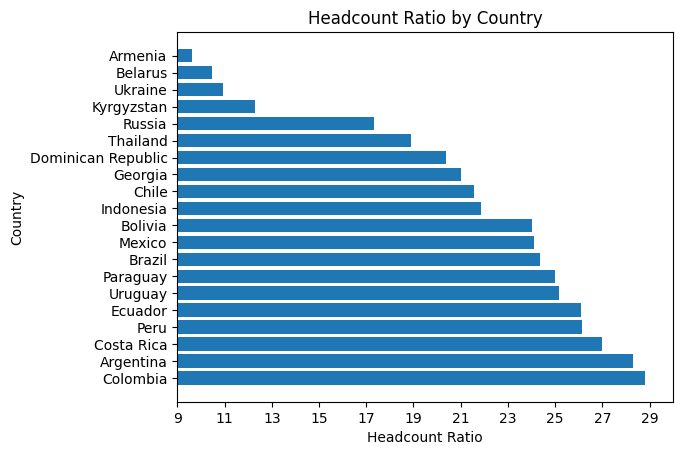

In [24]:
high20_df = final_df[final_df['Survey Year'] == 2020]
high20_df = high20_df.drop_duplicates(subset=['Country'], keep='last')
high20_df = high20_df.sort_values(by='Headcount Ratio 60 Median', ascending=False)
plt.title("Headcount Ratio by Country")
plt.ylabel("Country")
plt.xlabel("Headcount Ratio")
plt.barh(high20_df['Country'], high20_df['Headcount Ratio 60 Median'])
plt.xlim(9, 30)
plt.xticks(range(9, 31, 2))
plt.show()


 How has its rates changed over that period in time in comparison to the other top 10 countries?

---
I will make a time-rate line graph with color coded lines.

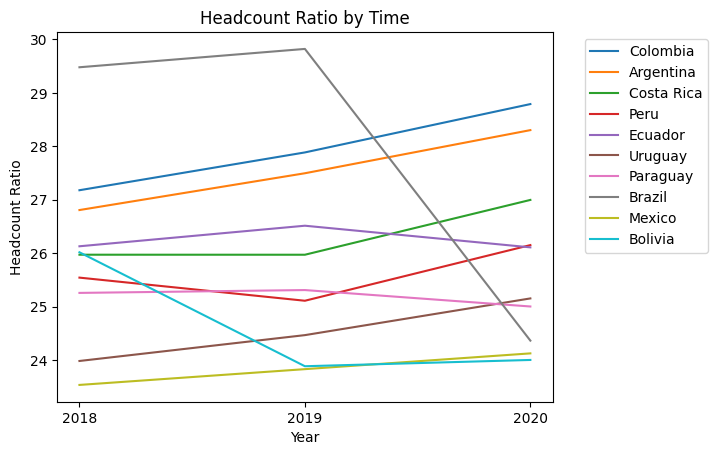

In [30]:
colombia_df = final_df[final_df['Country'] == 'Colombia']
colombia_df = colombia_df.sort_values(by='Year')
colombia_df = colombia_df.drop_duplicates(subset=['Year'], keep='last')
argentina_df = final_df[final_df['Country'] == 'Argentina']
argentina_df = argentina_df.sort_values(by='Year')
argentina_df = argentina_df.drop_duplicates(subset=['Year'], keep='last')
costarica_df = final_df[final_df['Country'] == 'Costa Rica']
costarica_df = costarica_df.sort_values(by='Year')
costarica_df = costarica_df.drop_duplicates(subset=['Year'], keep='last')
peru_df = final_df[final_df['Country'] == 'Peru']
peru_df = peru_df.sort_values(by='Year')
peru_df = peru_df.drop_duplicates(subset=['Year'], keep='last')
ecuador_df = final_df[final_df['Country'] == 'Ecuador']
ecuador_df = ecuador_df.sort_values(by='Year')
ecuador_df = ecuador_df.drop_duplicates(subset=['Year'], keep='last')
uruguay_df = final_df[final_df['Country'] == 'Uruguay']
uruguay_df = uruguay_df.sort_values(by='Year')
uruguay_df = uruguay_df.drop_duplicates(subset=['Year'], keep='last')
paraguay_df = final_df[final_df['Country'] == 'Paraguay']
paraguay_df = paraguay_df.sort_values(by='Year')
paraguay_df = paraguay_df.drop_duplicates(subset=['Year'], keep='last')
brazil_df = final_df[final_df['Country'] == 'Brazil']
brazil_df = brazil_df.sort_values(by='Year')
brazil_df = brazil_df.drop_duplicates(subset=['Year'], keep='last')
mexico_df = final_df[final_df['Country'] == 'Mexico']
mexico_df = mexico_df.sort_values(by='Year')
mexico_df = mexico_df.drop_duplicates(subset=['Year'], keep='last')
bolivia_df = final_df[final_df['Country'] == 'Bolivia']
bolivia_df = bolivia_df.sort_values(by='Year')
bolivia_df = bolivia_df.drop_duplicates(subset=['Year'], keep='last')

plt.plot(colombia_df['Year'], colombia_df['Headcount Ratio 60 Median'], label='Colombia')
plt.plot(argentina_df['Year'], argentina_df['Headcount Ratio 60 Median'], label='Argentina')
plt.plot(costarica_df['Year'], costarica_df['Headcount Ratio 60 Median'], label='Costa Rica')
plt.plot(peru_df['Year'], peru_df['Headcount Ratio 60 Median'], label='Peru')
plt.plot(ecuador_df['Year'], ecuador_df['Headcount Ratio 60 Median'], label='Ecuador')
plt.plot(uruguay_df['Year'], uruguay_df['Headcount Ratio 60 Median'], label='Uruguay')
plt.plot(paraguay_df['Year'], paraguay_df['Headcount Ratio 60 Median'], label='Paraguay')
plt.plot(brazil_df['Year'], brazil_df['Headcount Ratio 60 Median'], label='Brazil')
plt.plot(mexico_df['Year'], mexico_df['Headcount Ratio 60 Median'], label='Mexico')
plt.plot(bolivia_df['Year'], bolivia_df['Headcount Ratio 60 Median'], label='Bolivia')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Headcount Ratio by Time")
plt.xlabel("Year")
plt.ylabel("Headcount Ratio")
plt.ticklabel_format(useOffset=False, style='plain')
plt.xticks(range(2018, 2021, 1))
plt.show()

In [26]:
new_df = pd.concat([colombia_df, argentina_df, costarica_df, peru_df, ecuador_df])
new_df

,Country,Year,Survey Year,Headcount Ratio International Povline,Headcount 1000,Headcount Ratio 60 Median,Mean,Median,Gini,Mld,Palma Ratio
2852,Colombia,2018,2018.0,4.498261,25474258.0,27.177440,15.505493,9.715068,0.504187,0.457140,3.287686
2853,Colombia,2019,2019.0,5.284738,26096343.0,27.884933,15.541571,9.614681,0.513350,0.477734,3.477019
2854,Colombia,2020,2020.0,10.821042,30908407.0,28.789562,13.172428,7.795910,0.541740,0.554069,4.135306
2488,Argentina,2018,2018.0,0.767470,7862786.0,26.806520,26.796219,20.573063,0.413425,0.308587,1.994490
2489,Argentina,2019,2019.0,0.784007,9122527.0,27.495096,26.095949,19.475420,0.429059,0.332231,2.179824
2490,Argentina,2020,2020.0,1.074727,11296746.0,28.302175,22.843547,17.233385,0.423433,0.320525,2.113704
2890,Costa Rica,2018,2018.0,1.505753,1309054.0,25.970705,25.642475,16.596836,0.479685,0.410518,2.843479
2891,Costa Rica,2019,2019.0,1.057139,1371033.0,25.970213,25.529034,16.231756,0.481878,0.408292,2.870184
2892,Costa Rica,2020,2020.0,2.215688,1777224.0,26.995970,22.207889,13.916160,0.492503,0.436053,3.056650
4192,Peru,2018,2018.0,3.569299,15724448.0,25.541906,13.642751,10.165176,0.423876,0.318986,2.113545
